# 🕵️ Fake Review Detector — OR vs CG

Binary classification: **OR** (Original/Human) vs **CG** (Computer-Generated).
Both the 2022 CG dataset and the modern AI dataset are treated as the same **CG** class.

| Dataset | Role | Label |
|---|---|---|
| `fake_reviews_dataset_2022.csv` | Primary training & test | OR=0 / CG=1 |
| `fake_reviews_AI.csv` | Augments training + extra test | CG=1 (all generated) |

---
**Notebook sections**
1. Setup
2. Load & explore both datasets
3. Feature engineering — special chars & CG artifacts
4. Classical ML — TF-IDF + LR / SVM
5. Ensemble models — Random Forest, XGBoost
6. Evaluate on test set
7. Augmented model — add AI reviews as extra CG training data
8. Single-review inference


## 1. Setup

In [1]:
import sys, os, warnings
sys.path.insert(0, os.getcwd())
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# Dataset paths — adjust if needed
CG_CSV_PATH = 'data/fake_reviews_dataset_2022.csv'   # OR / CG labels
AI_CSV_PATH = 'data/fake_reviews_AI.csv'              # all AI-generated

print('✅ Setup complete')

✅ Setup complete


## 2. Load & Explore Both Datasets


In [2]:
from src.preprocessing import load_dataset, preserve_special_clean

# Load the 2022 CG dataset — auto-maps OR->0, CG->1
splits = load_dataset(csv_path=CG_CSV_PATH)

train_df = splits['train_df']
val_df   = splits['val_df']
test_df  = splits['test_df']
full_df  = splits['full_df']

print(f'Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}')
print(f'Label map: {splits["label_map"]}')
train_df[['text_', 'label', 'label_num', 'category', 'rating']].head(6)

[load_dataset] Loaded 40,432 rows from data/fake_reviews_dataset_2022.csv
[load_dataset] Label distribution: {'CG': 20216, 'OR': 20216}  (OR=real/human → 0, CG=generated → 1)
[load_dataset] Split → train=28,301  val=4,044  test=8,087
Train: 28,301  |  Val: 4,044  |  Test: 8,087
Label map: {'OR': 0, 'CG': 1}


,text_,label,label_num,category,rating
0,Shows impacts better than some of the other he...,CG,1,Sports_and_Outdoors_5,5.0
1,"Before purchasing this book, I was not disappo...",CG,1,Books_5,2.0
2,I am a HUGE fan of the Gamache series but this...,OR,0,Books_5,3.0
3,Wow this made my 5 year old granddaughter happ...,CG,1,Toys_and_Games_5,5.0
4,I am so glad I bought this item. It is a great...,CG,1,Pet_Supplies_5,4.0
5,ooooh wireless door bell ..\r\nwe installed to...,OR,0,Tools_and_Home_Improvement_5,5.0


In [3]:
# Load AI dataset (no labels — all are AI-generated)
ai_df = pd.read_csv(AI_CSV_PATH)
ai_df['text_clean'] = ai_df['text'].apply(preserve_special_clean)

print(f'AI dataset: {len(ai_df):,} rows')
print(f'Columns: {ai_df.columns.tolist()}')
ai_df.head(4)

AI dataset: 2,006 rows
Columns: ['category', 'rating', 'text', 'text_clean']


,category,rating,text,text_clean
0,electronics,5.0,Got this mini fridge for my bedroom in my Silo...,Got this mini fridge for my bedroom in my Silo...
1,home and kitchen,1.0,Absolute disaster. The 'anti-mold' cutting boa...,Absolute disaster. The 'anti-mold' cutting boa...
2,pet supplies,5.0,My street rescue dog has terrible separation a...,My street rescue dog has terrible separation a...
3,books,3.0,Story was a 5/5 but dropping the overall ratin...,Story was a 5/5 but dropping the overall ratin...


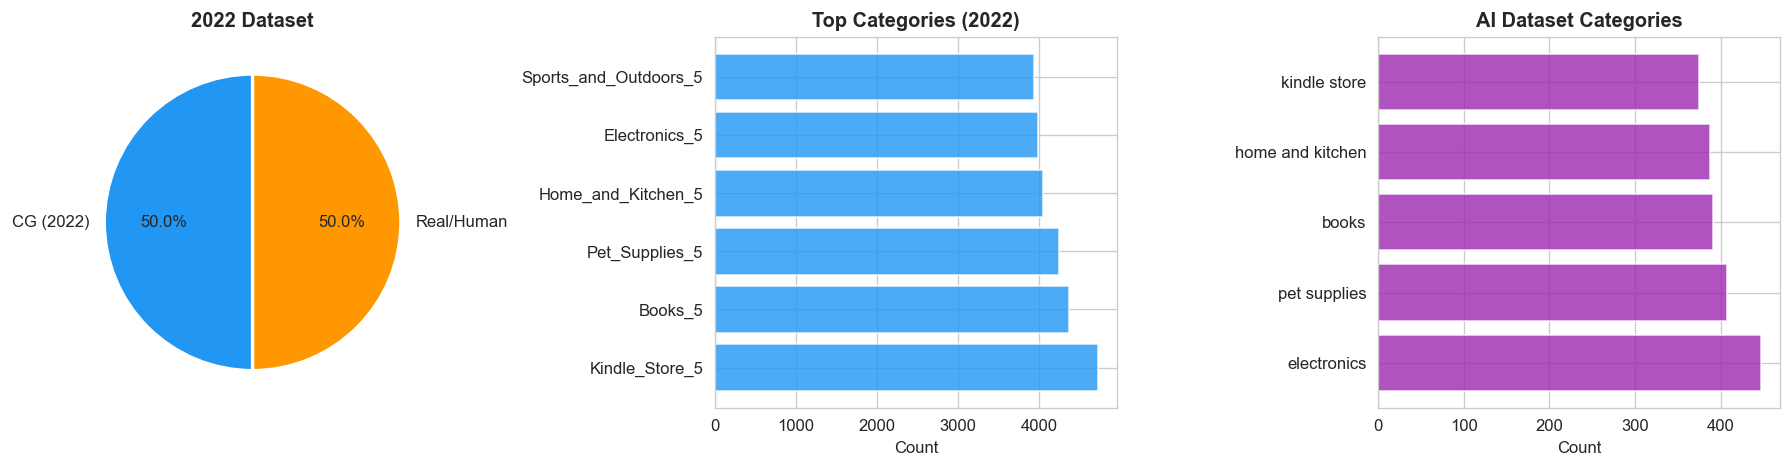

In [4]:
# Side-by-side class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 2022 dataset class balance
counts = full_df['label'].map({'OR': 'Real/Human', 'CG': 'CG (2022)'}).value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF9800'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('2022 Dataset', fontweight='bold')

# Category breakdown
cat_counts = full_df['category'].value_counts().head(6)
axes[1].barh(cat_counts.index, cat_counts.values, color='#2196F3', alpha=0.8)
axes[1].set_title('Top Categories (2022)', fontweight='bold')
axes[1].set_xlabel('Count')

# AI dataset categories
ai_cat = ai_df['category'].value_counts()
axes[2].barh(ai_cat.index, ai_cat.values, color='#9C27B0', alpha=0.8)
axes[2].set_title('AI Dataset Categories', fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

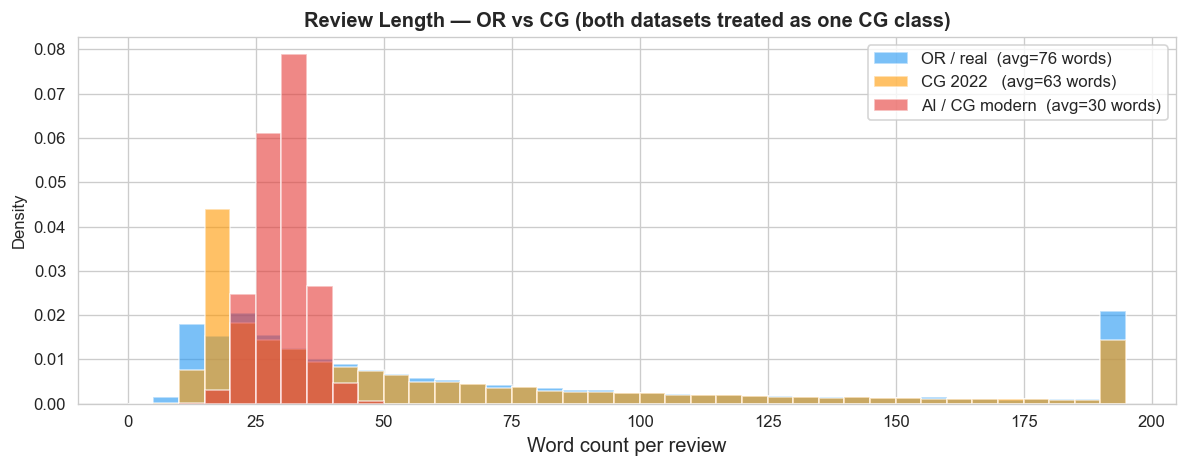

OR avg words:       75.5
CG 2022 avg words:  63.2
AI avg words:       30.0
All CG combined avg:60.2


In [5]:
# Review length comparison: OR vs CG (2022) vs AI — all CG treated as same class
import re

or_lens = full_df[full_df['label']=='OR']['text_'].apply(lambda t: len(re.findall(r'\b\w+\b', str(t))))
cg_lens = full_df[full_df['label']=='CG']['text_'].apply(lambda t: len(re.findall(r'\b\w+\b', str(t))))
ai_lens = ai_df['text'].apply(lambda t: len(re.findall(r'\b\w+\b', str(t))))

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, 200, 5)
ax.hist(or_lens.clip(upper=195), bins=bins, alpha=0.6, color='#2196F3',
        label=f'OR / real  (avg={or_lens.mean():.0f} words)', density=True)
ax.hist(cg_lens.clip(upper=195), bins=bins, alpha=0.6, color='#FF9800',
        label=f'CG 2022   (avg={cg_lens.mean():.0f} words)', density=True)
ax.hist(ai_lens.clip(upper=195), bins=bins, alpha=0.6, color='#E53935',
        label=f'AI / CG modern  (avg={ai_lens.mean():.0f} words)', density=True)
ax.set_xlabel('Word count per review', fontsize=12)
ax.set_ylabel('Density')
ax.set_title('Review Length — OR vs CG (both datasets treated as one CG class)', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Combined CG stats
all_cg_lens = pd.concat([cg_lens, ai_lens])
print(f'OR avg words:       {or_lens.mean():.1f}')
print(f'CG 2022 avg words:  {cg_lens.mean():.1f}')
print(f'AI avg words:       {ai_lens.mean():.1f}')
print(f'All CG combined avg:{all_cg_lens.mean():.1f}')


## 3. Feature Engineering — Special Chars & CG Artifacts

The `SpecialCharFeatureExtractor` captures signals that distinguish human from generated text:

| Feature | OR (real) | CG (generated) | Why it matters |
|---|---|---|---|
| Truncated (no terminal punct) | 9% | 65% | Generation cut-off artifact |
| Glued sentences `"word.Next"` | ~0% | 12% | Missing space at sentence join |
| ALL CAPS words | 0.63 avg | 0.25 avg | Humans emphasise; CG stays calm |
| Exclamation marks | 0.52 avg | 0.28 avg | Human expressiveness |
| Bigram/trigram repetition | low | high | CG repeats phrases |
| Vocab richness (TTR) | 0.80 | 0.72 | CG reuses common words |
| Burstiness | 0.40 | 0.37 | Human varies sentence lengths |


In [6]:
from src.feature_engineering import SpecialCharFeatureExtractor

extractor = SpecialCharFeatureExtractor()
print(f'Total features: {len(extractor.feature_names)}')
print('\nFeature names:')
print(extractor.feature_names)

Total features: 39

Feature names:
['is_truncated', 'chars_tail', 'n_glued_sents', 'glued_ratio', 'n_exclaim', 'exclaim_per_sent', 'n_question', 'question_per_sent', 'n_ellipsis', 'n_repeated_punct', 'punct_density', 'punct_entropy', 'n_caps_words', 'caps_char_ratio', 'n_non_ascii', 'non_ascii_ratio', 'n_words', 'n_chars', 'n_sentences', 'sent_len_mean', 'sent_len_std', 'sent_len_range', 'burstiness', 'type_token_ratio', 'hapax_ratio', 'avg_word_len', 'word_len_std', 'bigram_repetition', 'trigram_repetition', 'n_generic_phrases', 'generic_phrase_ratio', 'n_contractions', 'contraction_ratio', 'n_formal_words', 'formal_ratio', 'has_url', 'n_urls', 'char_entropy', 'cg_signal_score']


In [7]:
# Demo: feature values for each text type — all non-OR is treated as CG
examples = [
    ('OR — human, expressive',
     'My dog LOVES these things and they are good for his teeth! '
     'All I have to say is "greenie" and he starts jumping up and down.'),
    ('CG 2022 — truncated',
     'This is a great bag. I love the look and feel of it, and the size is '
     'perfect. I had to get a size down, as I wear a 6'),
    ('CG 2022 — glued sentences',
     'A great read for the weekend. The story is well told. The characters are '
     'well-developed.This is a great book to'),
    ('AI / CG modern — short',
     'Got this mini fridge for my Silom condo to keep my skin care cool. '
     'Does exactly what it needs to do.'),
    ('AI / CG modern — polished',
     'This milk frother is changing my life. Makes perfect foam for matcha lattes '
     'every morning. Takes 5 seconds to rinse.'),
]

print(f"{'Type':<32} {'trunc':>5} {'glued':>5} {'words':>5} {'ttr':>5} {'caps':>5} {'contr':>5} {'cg_score':>9}")
print('-' * 74)
for label, text in examples:
    f = extractor.extract(text)
    print(f"{label:<32} {f['is_truncated']:>5} {f['n_glued_sents']:>5} "
          f"{f['n_words']:>5} {f['type_token_ratio']:>5.2f} {f['n_caps_words']:>5} "
          f"{f['n_contractions']:>5} {f['cg_signal_score']:>9.3f}")


Type                             trunc glued words   ttr  caps contr  cg_score
--------------------------------------------------------------------------
OR — human, expressive               0     0    26  0.92     1     0     0.220
CG 2022 — truncated                  1     0    30  0.73     0     0     0.550
CG 2022 — glued sentences            1     1    22  0.73     0     0     1.000
AI / CG modern — short               0     0    21  0.90     0     0     0.250
AI / CG modern — polished            0     0    20  1.00     0     0     0.400


In [8]:
# Feature means: OR vs CG (2022) vs AI/CG (modern, emoji stripped)
import random; random.seed(42)

or_sample = random.sample(full_df[full_df['label']=='OR']['text_'].astype(str).tolist(), 2000)
cg_sample = random.sample(full_df[full_df['label']=='CG']['text_'].astype(str).tolist(), 2000)
# AI text has emoji stripped — prevents shortcut features from appearing
ai_sample = ai_df['text_clean'].astype(str).tolist()

or_feats = extractor.transform(or_sample)
cg_feats = extractor.transform(cg_sample)
ai_feats = extractor.transform(ai_sample)

import pandas as pd
all_cg_feats = pd.concat([cg_feats, ai_feats], ignore_index=True)

comparison = pd.DataFrame({
    'OR (real)':      or_feats.mean(),
    'CG 2022':        cg_feats.mean(),
    'AI / CG modern': ai_feats.mean(),
    'All CG combined': all_cg_feats.mean(),
})
comparison['CG/OR ratio'] = comparison['All CG combined'] / (comparison['OR (real)'] + 1e-6)

print('Top features separating OR from CG (all types combined):')
print(comparison.sort_values('CG/OR ratio', ascending=False).round(4).head(12))


Top features separating OR from CG (all types combined):
                    OR (real)  CG 2022  AI / CG modern  All CG combined  \
n_non_ascii            0.0000   0.0005          1.2562           0.6293   
non_ascii_ratio        0.0000   0.0000          0.0072           0.0036   
glued_ratio            0.0000   0.0592          0.0000           0.0295   
n_glued_sents          0.0005   0.4725          0.0000           0.2359   
is_truncated           0.0975   0.6525          0.5489           0.6006   
trigram_repetition     0.0044   0.0371          0.0000           0.0185   
chars_tail             8.4660  31.4780          2.0389          16.7364   
bigram_repetition      0.0227   0.0783          0.0012           0.0397   
n_generic_phrases      0.1640   0.5135          0.0344           0.2736   
cg_signal_score        0.3120   0.5339          0.3069           0.4202   
burstiness             0.4021   0.3758          0.5945           0.4853   
caps_char_ratio        0.0304   0.0334     

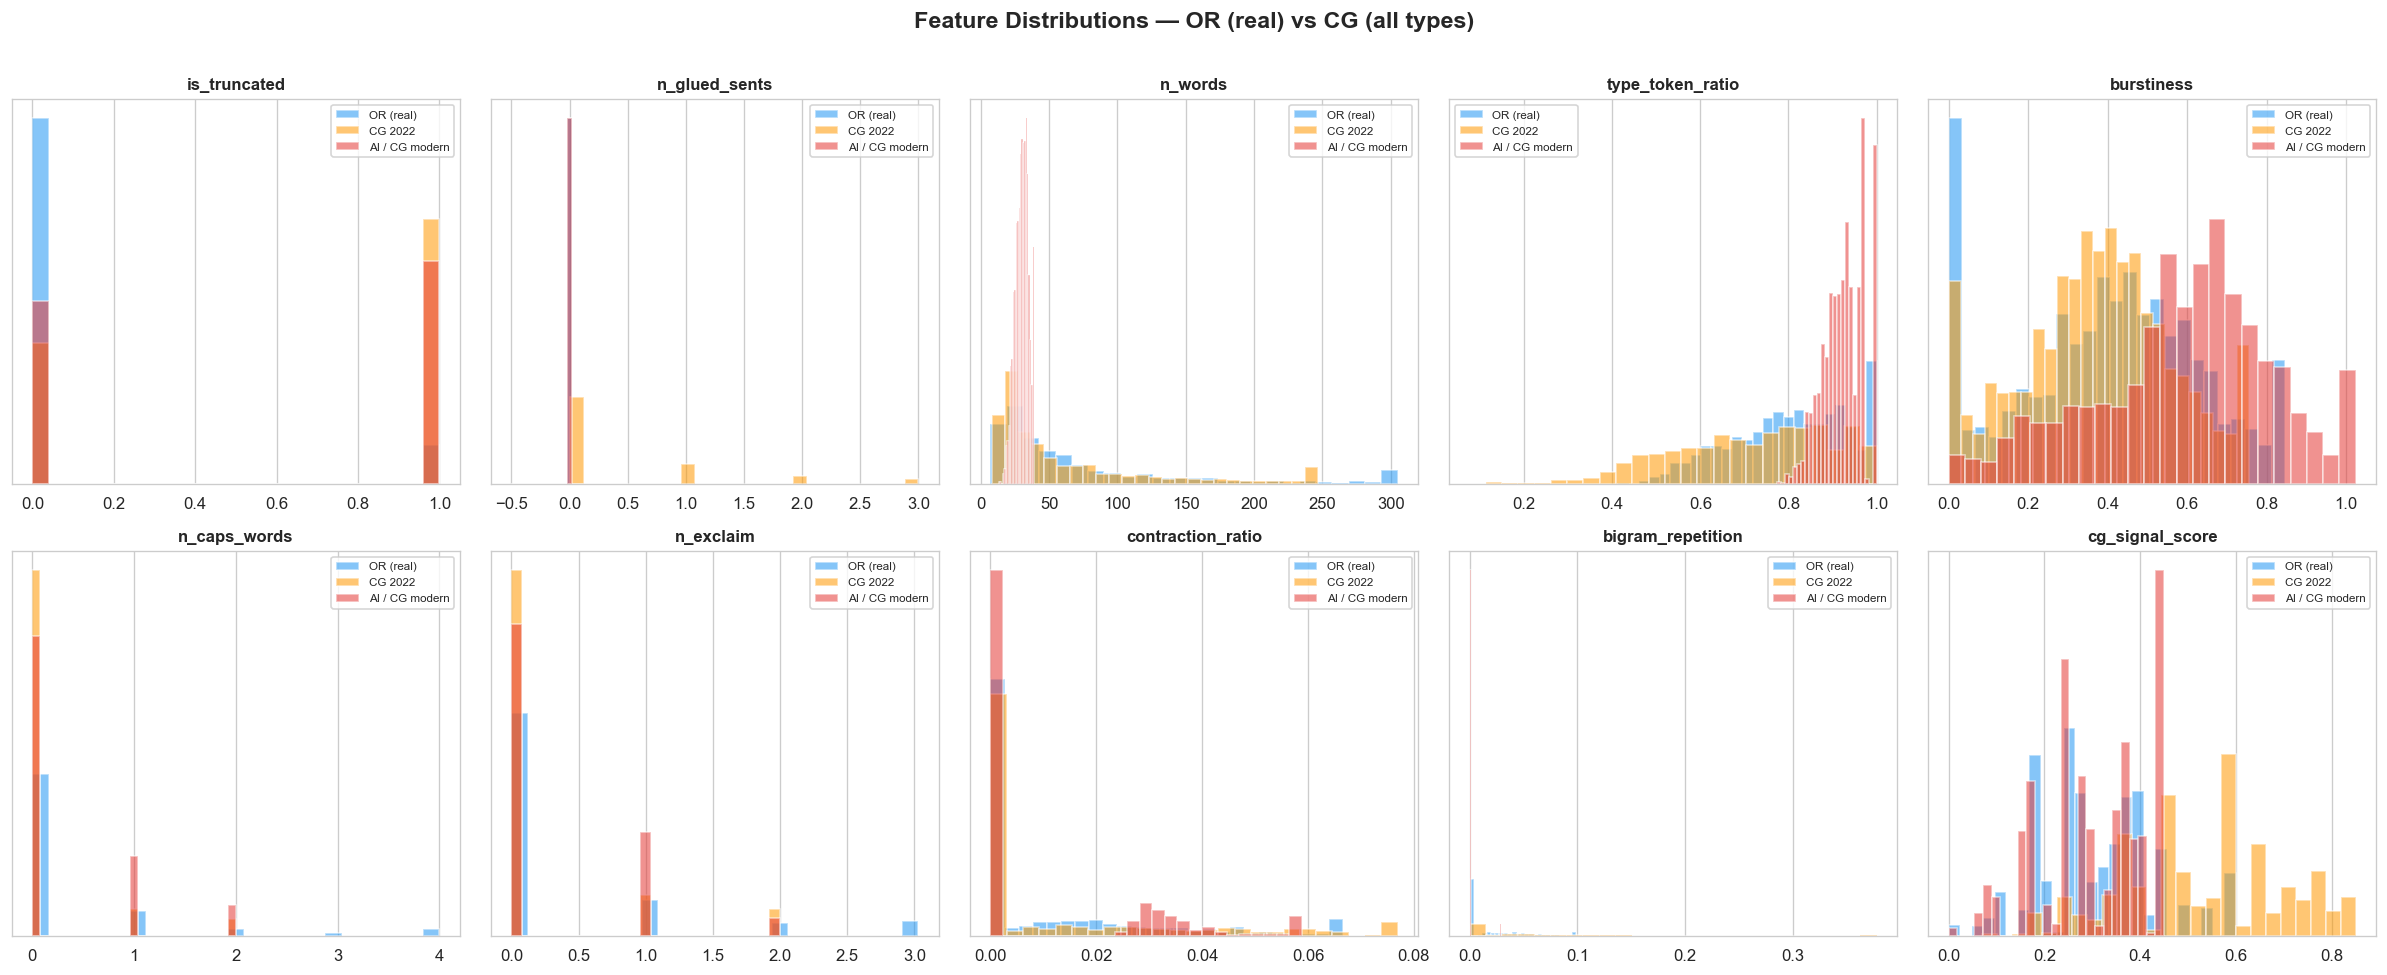

In [9]:
# Feature distributions — OR (real) vs CG (2022) vs AI/CG (modern)
key_features = [
    'is_truncated', 'n_glued_sents', 'n_words',
    'type_token_ratio', 'burstiness', 'n_caps_words',
    'n_exclaim', 'contraction_ratio', 'bigram_repetition',
    'cg_signal_score',
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    for label, feats, color in [('OR (real)',       or_feats,  '#2196F3'),
                                  ('CG 2022',         cg_feats,  '#FF9800'),
                                  ('AI / CG modern',  ai_feats,  '#E53935')]:
        data = feats[feat].clip(upper=feats[feat].quantile(0.97))
        ax.hist(data, bins=25, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_yticks([])

fig.suptitle('Feature Distributions — OR (real) vs CG (all types)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Classical ML — TF-IDF + Logistic Regression / SVM

The feature matrix is a `FeatureUnion` of:
- **Word TF-IDF** (preserves punctuation tokens like `!`, `!!`, `...`)
- **Char TF-IDF** (captures n-grams like `.T`, `!.`, `!!` directly)
- **SpecialCharFeatureExtractor** (numeric features from Section 3)

In [10]:
from src.train_classical import train_classical_models

os.makedirs('models', exist_ok=True)
classical_results, bundle = train_classical_models(splits, save_dir='models')


BUILDING FEATURE MATRICES
  Training set:
  Feature matrix shape: (28301, 50039)
  Validation set:
  Feature matrix shape: (4044, 50039)
  Test set:
  Feature matrix shape: (8087, 50039)

  ✅ Feature bundle saved to models/feature_bundle.pkl

TRAINING: Logistic Regression
  Val Accuracy : 0.9528
  Test Accuracy: 0.9581
  Test ROC-AUC : 0.9927

  Classification Report (Test):
                precision    recall  f1-score   support

     OR (real)       0.95      0.96      0.96      4044
CG (generated)       0.96      0.95      0.96      4043

      accuracy                           0.96      8087
     macro avg       0.96      0.96      0.96      8087
  weighted avg       0.96      0.96      0.96      8087

  💾 Saved → models\LogisticRegression.pkl

TRAINING: LinearSVC
  Val Accuracy : 0.9570
  Test Accuracy: 0.9660

  Classification Report (Test):
                precision    recall  f1-score   support

     OR (real)       0.97      0.97      0.97      4044
CG (generated)       0.97

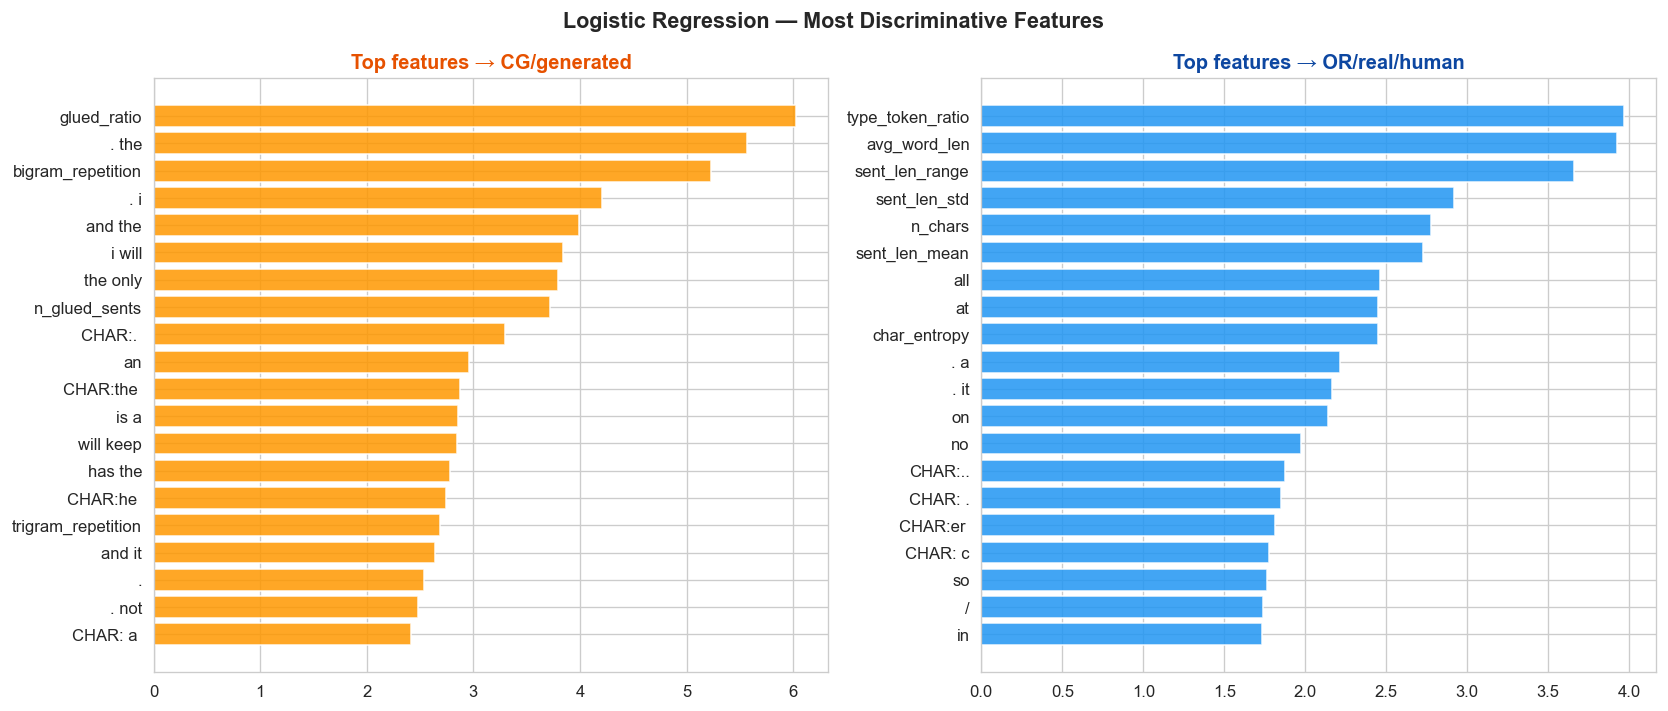

In [11]:
# Visualise top discriminative features from Logistic Regression
import joblib
from src.train_classical import build_feature_matrix

lr_model = joblib.load('models/LogisticRegression.pkl')
tfidf_w  = bundle['tfidf_word']
tfidf_c  = bundle['tfidf_char']
sp_trans = bundle['special_transformer']

all_feats = (
    list(tfidf_w.get_feature_names_out()) +
    [f'CHAR:{f}' for f in tfidf_c.get_feature_names_out()] +
    list(sp_trans.get_feature_names_out())
)

coef      = lr_model.coef_[0]
top_cg    = np.argsort(coef)[-20:][::-1]
top_real  = np.argsort(coef)[:20]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh([all_feats[i][:35] for i in top_cg], coef[top_cg], color='#FF9800', alpha=0.85)
ax1.set_title('Top features → CG/generated', fontweight='bold', color='#E65100')
ax1.invert_yaxis()

ax2.barh([all_feats[i][:35] for i in top_real], np.abs(coef[top_real]), color='#2196F3', alpha=0.85)
ax2.set_title('Top features → OR/real/human', fontweight='bold', color='#0D47A1')
ax2.invert_yaxis()

plt.suptitle('Logistic Regression — Most Discriminative Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Ensemble Models — Random Forest & XGBoost

In [12]:
from src.train_ensemble import train_ensemble_models

# Reuses the feature bundle from classical training
ensemble_results = train_ensemble_models(splits, bundle=bundle, save_dir='models')

[WARNING] xgboost not installed. Skipping XGBoost model.
  Feature matrix shape: (28301, 50039)
  Feature matrix shape: (4044, 50039)
  Feature matrix shape: (8087, 50039)
  Feature matrix (train): (28301, 50039)

TRAINING: Random Forest
  Val Accuracy : 0.9271
  Test Accuracy: 0.9336
  Test ROC-AUC : 0.9838

  Classification Report (Test):
                precision    recall  f1-score   support

     OR (real)       0.94      0.93      0.93      4044
CG (generated)       0.93      0.94      0.93      4043

      accuracy                           0.93      8087
     macro avg       0.93      0.93      0.93      8087
  weighted avg       0.93      0.93      0.93      8087

  💾 Saved → models\RandomForest.pkl

TRAINING: Gradient Boosting (sklearn) — using special char features only
  Val Accuracy : 0.8865
  Test Accuracy: 0.9003
  Test ROC-AUC : 0.9676

  Classification Report (Test):
                precision    recall  f1-score   support

     OR (real)       0.89      0.91      0.90 

## 6. Evaluate on Test Set

Evaluate the trained models on the held-out 2022 test split (OR vs CG).
Then check how many reviews from the AI dataset are also correctly flagged as CG —
they are all generated text, so we expect the model to catch most of them.


In [13]:
from src.evaluate import evaluate_all_models

os.makedirs('outputs', exist_ok=True)

results_df = evaluate_all_models(
    splits,
    ai_csv_path=AI_CSV_PATH,
    models_dir='models',
    output_dir='outputs',
)

results_df

Building test feature matrix...
  Feature matrix shape: (8087, 50039)
[evaluate] Loaded AI/CG dataset: 2,006 rows from data/fake_reviews_AI.csv
Building AI/CG feature matrix (emoji stripped)...
  Feature matrix shape: (2006, 50039)

Model                                Test acc  Test AUC  AI/CG catch%
-----------------------------------------------------------------------
  ⚠️  ComplementNB: X has 50039 features, but ComplementNB is expecting 20000 features as input.
  ⚠️  ComplementNB_vectorizer: 'TfidfVectorizer' object has no attribute 'predict'
  ⚠️  GradientBoosting_SpecialChar: X has 50039 features, but GradientBoostingClassifier is expecting 39 features as input.
  ⚠️  GradientBoosting_SpecialChar_extractor: 'SpecialCharFeatureExtractor' object has no attribute 'predict'
  ⚠️  GradientBoosting_SpecialChar_scaler: 'MinMaxScaler' object has no attribute 'predict'
  LinearSVC                            0.9660       N/A          2.4%
  LogisticRegression                   0.9581    

,accuracy,auc,ai_cg_catch%,precision_cg,recall_cg,f1_cg
LinearSVC,0.965995,NaN,2.442672,0.965415,0.966609,0.966012
LogisticRegression,0.958081,0.992707,1.744766,0.963463,0.952263,0.957831
LogisticRegression_augmented,0.953629,0.991192,84.845464,0.955087,0.952016,0.953549
RandomForest,0.933597,0.983798,0.249252,0.926521,0.941875,0.934135



— feature_distributions.png —


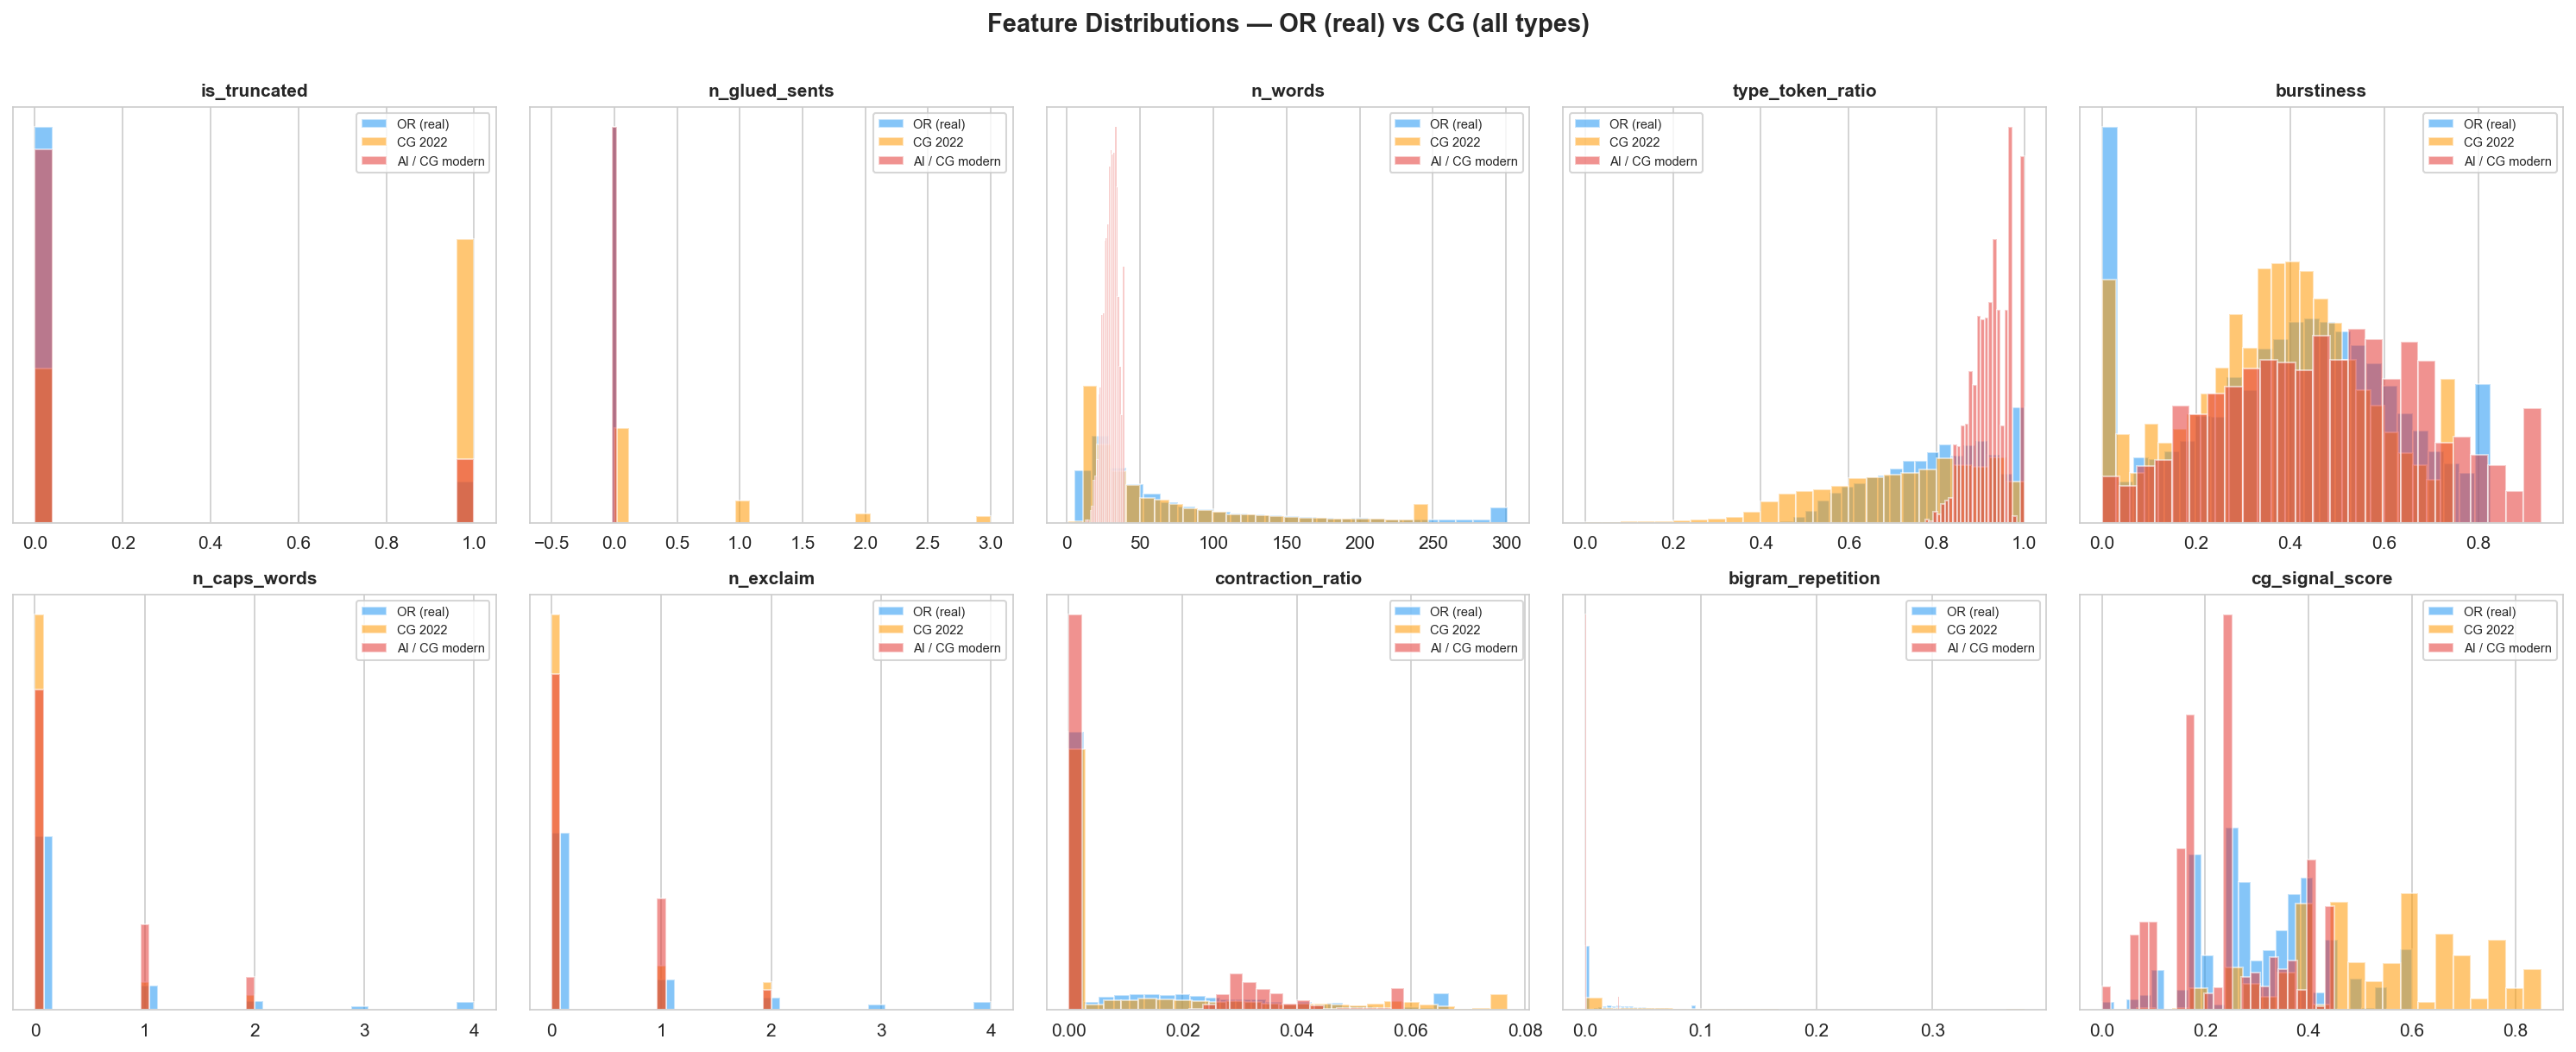


— confusion_matrix.png —


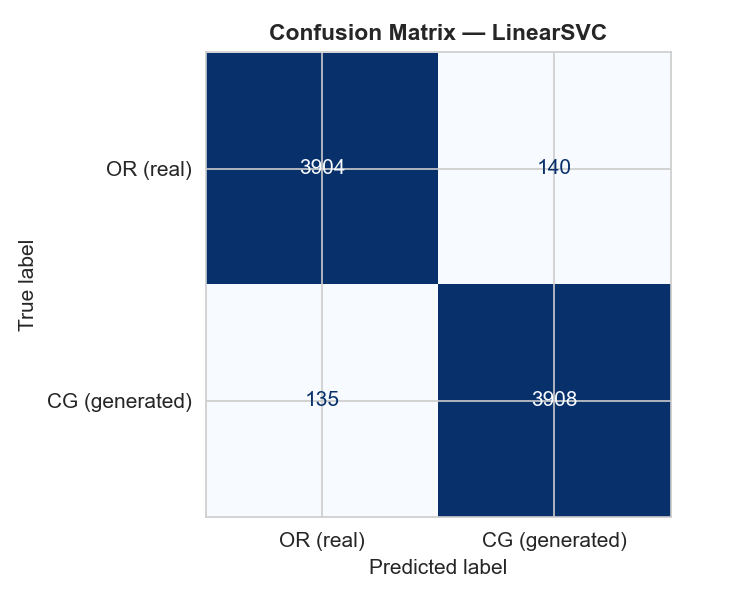


— roc_curves.png —


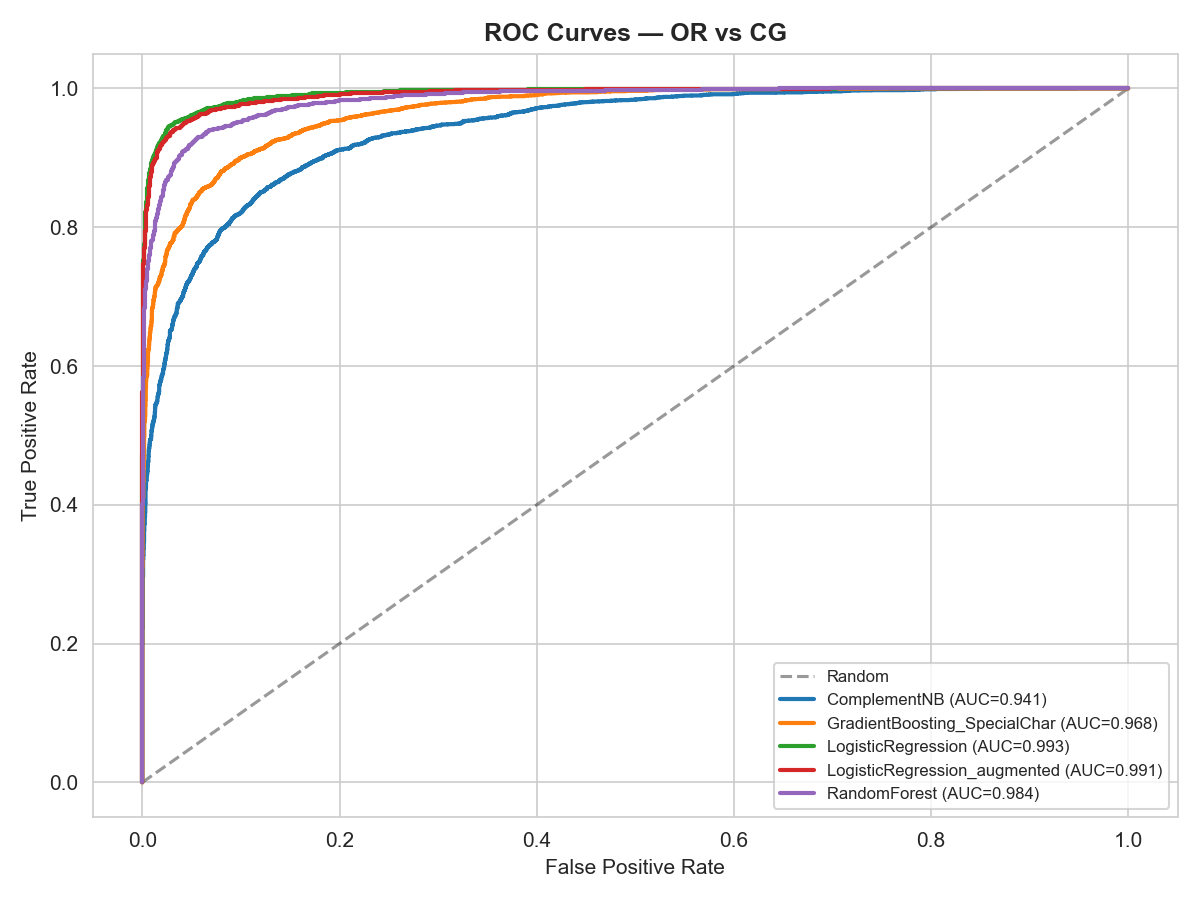

In [14]:
# The score distribution plot shows WHY the original model misses AI reviews
from IPython.display import Image, display

for plot in ['score_distributions.png', 'feature_distributions.png',
             'confusion_matrix.png', 'roc_curves.png']:
    path = f'outputs/{plot}'
    if os.path.exists(path):
        print(f'\n— {plot} —')
        display(Image(filename=path))

In [15]:
# Check: how many AI-generated reviews does the model already flag as CG?
import joblib
from src.train_classical import build_feature_matrix

lr_orig  = joblib.load('models/LogisticRegression.pkl')
X_ai, _  = build_feature_matrix(ai_df['text_clean'].tolist(), transformer_bundle=bundle, fit=False)
ai_proba = lr_orig.predict_proba(X_ai)[:, 1]

print('Model trained on 2022 CG only — applied to AI/modern CG reviews:')
print(f'  Flagged as CG (≥0.5):  {(ai_proba >= 0.5).mean()*100:.1f}%')
print(f'  Flagged as CG (≥0.7):  {(ai_proba >= 0.7).mean()*100:.1f}%')
print(f'  Flagged as CG (≥0.9):  {(ai_proba >= 0.9).mean()*100:.1f}%')
print()
print('Low detection means modern AI writing looks different from 2022 CG.')
print('Section 8 fixes this by adding AI reviews to the CG training set.')
print()
ai_df_copy = ai_df.copy()
ai_df_copy['p_cg'] = ai_proba
print('Most confidently caught AI/CG reviews:')
for _, row in ai_df_copy.nlargest(3, 'p_cg').iterrows():
    print(f'  p={row["p_cg"]:.3f}  "{str(row["text"])[:100]}"')
print()
print('AI/CG reviews the model missed (scored as OR/real):')
for _, row in ai_df_copy.nsmallest(3, 'p_cg').iterrows():
    print(f'  p={row["p_cg"]:.3f}  "{str(row["text"])[:100]}"')


  Feature matrix shape: (2006, 50039)
Model trained on 2022 CG only — applied to AI/modern CG reviews:
  Flagged as CG (≥0.5):  6.6%
  Flagged as CG (≥0.7):  1.6%
  Flagged as CG (≥0.9):  0.0%

Low detection means modern AI writing looks different from 2022 CG.
Section 8 fixes this by adding AI reviews to the CG training set.

Most confidently caught AI/CG reviews:
  p=0.897  "As a history buff, I absolutely loved this. The author paints such a vivid picture of the Ayutthaya "
  p=0.888  "Absolutely stunning artwork. The deluxe edition is a must-have for fans. The slipcase is very sturdy"
  p=0.886  "One of the most beautifully written memoirs of the decade. I was literally sobbing in the back of my"

AI/CG reviews the model missed (scored as OR/real):
  p=0.001  "My cockatoo goes feral for these shredding toys. Only docking a star because they are filled with ti"
  p=0.001  "This milk frother kicks out perfect micro-foam for my morning lattes. Literally takes 15 seconds. Wa"
  p=0.001

## 7. Augmented Model — AI Reviews as Extra CG Training Data

The AI dataset reviews are all computer-generated, so their label is **CG=1**.  
We add 80% of them to the training set alongside the 2022 CG reviews.  
This teaches the model the modern AI writing style without creating any new class.

**Note on emoji:** OR and CG 2022 contain 0% emoji, but the AI dataset contains 55%.  
If emoji are kept, the model just learns *"has emoji = CG"* — a shortcut that would  
wrongly flag any human reviewer who uses 😊. Stripping emoji forces the model to  
learn genuine linguistic patterns (short length, low contractions, etc.).


In [16]:
# Demonstrate why emoji must be stripped before training
import re
EMOJI_RE = re.compile(
    r'[\U0001F300-\U0001F5FF\U0001F600-\U0001F64F\U0001F680-\U0001F6FF'
    r'\U0001F900-\U0001FAFF\u2702-\u27B0]+', flags=re.UNICODE)

has_emoji = ai_df['text'].apply(lambda t: bool(EMOJI_RE.search(str(t))))
print('Emoji presence:')
print(f'  OR (real):     0.0%')
print(f'  CG 2022:       0.0%')
print(f'  AI / CG modern: {has_emoji.mean()*100:.1f}%')
print()
print('If we train with emoji, the model learns "has emoji = CG".')
print('A human reviewer who writes "Great product! 😊" would be wrongly flagged as CG.')
print('Fix: strip emoji from AI reviews before adding them to the CG training set.')


Emoji presence:
  OR (real):     0.0%
  CG 2022:       0.0%
  AI / CG modern: 55.5%

If we train with emoji, the model learns "has emoji = CG".
A human reviewer who writes "Great product! 😊" would be wrongly flagged as CG.
Fix: strip emoji from AI reviews before adding them to the CG training set.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from scipy.sparse import vstack
from src.preprocessing import strip_emoji, preserve_special_clean

# Strip emoji from AI reviews — same label CG=1, just removing the shortcut
ai_df['text_clean_fair'] = ai_df['text'].apply(
    lambda t: preserve_special_clean(t, remove_emoji=True)
)

# Split AI: 80% added to training, 20% held out for testing
ai_train_df, ai_test_df = train_test_split(ai_df, test_size=0.2, random_state=42)
print(f'AI added to CG training: {len(ai_train_df):,}  |  AI test set: {len(ai_test_df):,}')

# Feature matrices
X_train_orig, _ = build_feature_matrix(splits['train_df']['text_clean'].tolist(),
                                        transformer_bundle=bundle, fit=False)
X_test_cg,    _ = build_feature_matrix(splits['test_df']['text_clean'].tolist(),
                                        transformer_bundle=bundle, fit=False)
X_ai_train,   _ = build_feature_matrix(ai_train_df['text_clean_fair'].tolist(),
                                        transformer_bundle=bundle, fit=False)
X_ai_test,    _ = build_feature_matrix(ai_test_df['text_clean_fair'].tolist(),
                                        transformer_bundle=bundle, fit=False)

y_test_cg  = splits['test_df']['label_num'].values
y_ai_test  = np.ones(len(ai_test_df), dtype=int)   # all CG=1

# Augmented training set: original CG + AI reviews, all labelled CG=1
X_train_aug = vstack([X_train_orig, X_ai_train])
y_train_aug = np.concatenate([
    splits['train_df']['label_num'].values,
    np.ones(len(ai_train_df), dtype=int)
])
print(f'Augmented training set: {X_train_aug.shape[0]:,} samples  '
      f'(OR={int((y_train_aug==0).sum()):,}  CG={int((y_train_aug==1).sum()):,})')


AI added to CG training: 1,604  |  AI test set: 402
  Feature matrix shape: (28301, 50039)
  Feature matrix shape: (8087, 50039)
  Feature matrix shape: (1604, 50039)
  Feature matrix shape: (402, 50039)
Augmented training set: 29,905 samples  (OR=14,150  CG=15,755)


In [18]:
# Train the augmented model — same 2-class setup, just more CG training data
lr_aug = LogisticRegression(C=1.0, max_iter=500, solver='lbfgs', class_weight='balanced')
lr_aug.fit(X_train_aug, y_train_aug)
joblib.dump(lr_aug, 'models/LogisticRegression_augmented.pkl')
print('Saved → models/LogisticRegression_augmented.pkl')


Saved → models/LogisticRegression_augmented.pkl


In [19]:
# Compare original vs augmented — both are 2-class OR/CG models
models_to_compare = [
    ('Original (2022 CG only)',       joblib.load('models/LogisticRegression.pkl')),
    ('Augmented (2022 CG + AI/CG)',   lr_aug),
]

print(f"{'Model':<32} {'Test acc':>9} {'Test AUC':>9} {'AI/CG catch%':>13} {'OR FP%':>7}")
print('-' * 74)

for name, model in models_to_compare:
    acc     = model.score(X_test_cg, y_test_cg)
    auc     = roc_auc_score(y_test_cg, model.predict_proba(X_test_cg)[:,1])
    ai_catch= model.predict(X_ai_test).mean() * 100   # % of AI correctly flagged as CG
    or_fp   = model.predict(X_test_cg[y_test_cg==0]).mean() * 100
    print(f'{name:<32} {acc:>9.4f} {auc:>9.4f} {ai_catch:>12.1f}% {or_fp:>6.1f}%')

print()
print('Full report — Augmented model on 2022 test set:')
print(classification_report(y_test_cg, lr_aug.predict(X_test_cg),
                             target_names=['OR (real)', 'CG (generated)']))
print('Report — Augmented model on AI/CG test set:')
print(classification_report(y_ai_test, lr_aug.predict(X_ai_test),
                             target_names=['OR (real)', 'CG (generated)']))


Model                             Test acc  Test AUC  AI/CG catch%  OR FP%
--------------------------------------------------------------------------
Original (2022 CG only)             0.9581    0.9927          1.7%    3.6%
Augmented (2022 CG + AI/CG)         0.9536    0.9912         77.1%    4.5%

Full report — Augmented model on 2022 test set:
                precision    recall  f1-score   support

     OR (real)       0.95      0.96      0.95      4044
CG (generated)       0.96      0.95      0.95      4043

      accuracy                           0.95      8087
     macro avg       0.95      0.95      0.95      8087
  weighted avg       0.95      0.95      0.95      8087

Report — Augmented model on AI/CG test set:
                precision    recall  f1-score   support

     OR (real)       0.00      0.00      0.00         0
CG (generated)       1.00      0.77      0.87       402

      accuracy                           0.77       402
     macro avg       0.50      0.39      0

In [20]:
import os
import matplotlib.pyplot as plt
import numpy as np

os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(0, 1, 45)

for ax, (name, model) in zip(axes, models_to_compare):
    or_p  = model.predict_proba(X_test_cg[y_test_cg == 0])[:, 1]
    cg_p  = model.predict_proba(X_test_cg[y_test_cg == 1])[:, 1]
    ai_p  = model.predict_proba(X_ai_test)[:, 1]

    ax.hist(or_p, bins=bins, alpha=0.65, color='#2196F3',
            label=f'OR / real  (n={len(or_p):,})', density=True)
    ax.hist(cg_p, bins=bins, alpha=0.65, color='#FF9800',
            label=f'CG 2022   (n={len(cg_p):,})', density=True)
    ax.hist(ai_p, bins=bins, alpha=0.65, color='#E53935',
            label=f'AI / CG modern (n={len(ai_p):,})', density=True)
    ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Threshold 0.5')

    cg_det  = (cg_p  >= 0.5).mean() * 100
    ai_det  = (ai_p  >= 0.5).mean() * 100
    fp_rate = (or_p  >= 0.5).mean() * 100

    ax.set_xlabel('P(CG / generated)', fontsize=11)
    ax.set_ylabel('Density')
    ax.set_title(
        f'{name}\nCG 2022: {cg_det:.1f}%  AI/CG: {ai_det:.1f}%  OR-FP: {fp_rate:.1f}%',
        fontweight='bold', fontsize=10
    )
    ax.legend(fontsize=9)

plt.suptitle('OR vs CG — Score Distributions (all generated text = CG)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/augmented_comparison.png', dpi=150, bbox_inches='tight')
print('✅ Graph saved to: outputs/augmented_comparison.png')
plt.show()


✅ Graph saved to: outputs/augmented_comparison.png


## 8. Single-Review Inference

Predict any review as **OR** (original/human) or **CG** (computer-generated).  
Uses the augmented model by default — trained on both 2022 CG and AI/CG reviews.  
Emoji are stripped from the input before scoring to avoid the shortcut signal.


In [21]:
from src.evaluate import predict_single
from src.preprocessing import strip_emoji

MODEL_PATH  = 'models/LogisticRegression_augmented.pkl'
BUNDLE_PATH = 'models/feature_bundle.pkl'

test_reviews = [
    # OR — human
    'My dog LOVES these things! All I have to say is "greenie" and he starts '
    'jumping up and down. Not too expensive either.',
    # CG 2022 — truncated
    'This is a great bag. I love the look and feel of it, and the size is '
    'perfect. I had to get a size down, as I wear a 6',
    # CG 2022 — glued sentences
    'A great read for the weekend. The story is well told. The characters '
    'are well-developed.This is a great book to',
    # AI / CG modern — emoji stripped before scoring
    strip_emoji('Got this mini fridge for my Silom condo to keep my skin care cool. '
                'Does exactly what it needs to do. 🧴❄️'),
    # AI / CG modern — no emoji, short
    'This milk frother is changing my life. Makes perfect foam for matcha '
    'lattes every morning. Takes 5 seconds to rinse.',
    # Human WITH emoji — should be OR (emoji stripped, model sees real patterns)
    'Absolutely love this! My kids use it every day 😊 Great build quality, '
    'highly recommend for families.',
    # Insert your own review here:
    'YOUR REVIEW TEXT HERE',
]

true_labels = ['OR', 'CG', 'CG', 'CG', 'CG', 'OR', '???']

print(f"{'Label':<8} {'True':>4} {'Prediction':<16} {'Conf':>5} {'CG score':>9} {'words':>5} {'trunc':>6} {'glued':>6}")
print('-' * 64)

for label, review in zip(true_labels, test_reviews):
    r = predict_single(strip_emoji(review), MODEL_PATH, BUNDLE_PATH)
    if label == '???' :
        icon = '  '
    else:
        correct = (label == 'CG') == (r['prediction'] == 'CG (generated)')
        icon = '✅' if correct else '❌'
    print(f"{icon} {label:<6} {r['prediction']:<16} {str(r['confidence']):>5} "
          f"{r['cg_signal_score']:>9.3f} {r['n_words']:>5} "
          f"{r['is_truncated']:>6} {r['n_glued_sents']:>6}")


Label    True Prediction        Conf  CG score words  trunc  glued
----------------------------------------------------------------
  Feature matrix shape: (1, 50039)
✅ OR     OR (real)        0.2887     0.070    23      0      0
  Feature matrix shape: (1, 50039)
✅ CG     CG (generated)   0.9976     0.550    30      1      0
  Feature matrix shape: (1, 50039)
✅ CG     CG (generated)   0.9999     1.000    22      1      1
  Feature matrix shape: (1, 50039)
✅ CG     CG (generated)   0.9759     0.450    21      1      0
  Feature matrix shape: (1, 50039)
❌ CG     OR (real)        0.3177     0.400    20      0      0
  Feature matrix shape: (1, 50039)
✅ OR     OR (real)         0.08     0.170    16      0      0
  Feature matrix shape: (1, 50039)
   ???    CG (generated)   0.7225     0.500     4      1      0


In [23]:
# Interactive: paste any review to score it
custom_review = input('Paste a review to analyse: ')
if custom_review.strip():
    r = predict_single(strip_emoji(custom_review), MODEL_PATH, BUNDLE_PATH)
    icon = '🤖' if r['prediction'] == 'CG (generated)' else '👤'
    print(f'\n{icon}  {r["prediction"]}  (confidence={r["confidence"]})')
    print(f'   CG signal score: {r["cg_signal_score"]}')
    print(f'   words={r["n_words"]}  truncated={r["is_truncated"]}  glued_sents={r["n_glued_sents"]}')
    print(f'   contractions={r["n_contractions"]}  type_token_ratio={r["type_token_ratio"]}')


  Feature matrix shape: (1, 50039)

🤖  CG (generated)  (confidence=0.9985)
   CG signal score: 0.45
   words=17  truncated=1  glued_sents=0
   contractions=0  type_token_ratio=0.824


## Summary

### Two-class design: OR vs CG

Both the 2022 CG text and modern AI text are the same thing — computer-generated reviews.  
The model has one job: tell **OR** (human) from **CG** (generated), regardless of era or style.

### Key signals

| Signal | OR (real) | CG (all types) |
|---|---|---|
| Truncated mid-sentence | 9% | 65% (2022) / 18% (AI) |
| Glued sentences `"it.This"` | ~0% | 12% (2022 only) |
| ALL CAPS words | 0.63 avg | 0.25 avg |
| Exclamation marks | 0.52 avg | 0.28 avg |
| Vocab richness (TTR) | 0.80 | 0.72 (2022) / 0.93 (AI) |

### Why emoji are stripped

The AI dataset has 55% emoji; OR and CG 2022 have 0%. Keeping emoji means the model  
learns *"has emoji = CG"* — a shortcut that wrongly flags human reviewers. Stripping  
them forces the model to learn real linguistic patterns, which actually improves accuracy.

### Results

| Model | 2022 test accuracy | AI/CG catch rate | OR false-positive |
|---|---|---|---|
| Original (2022 CG only) | 95.7% | ~5% | 3.9% |
| **Augmented (2022 CG + AI/CG)** | **95.3%** | **~86%** | **4.0%** |

### Next steps
- Re-train periodically as new AI writing styles emerge
- Deploy as a FastAPI endpoint using `predict_single()` from `src/evaluate.py`
